In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

from students.kayashev.lesson3 import Exercise

(1797, 64)


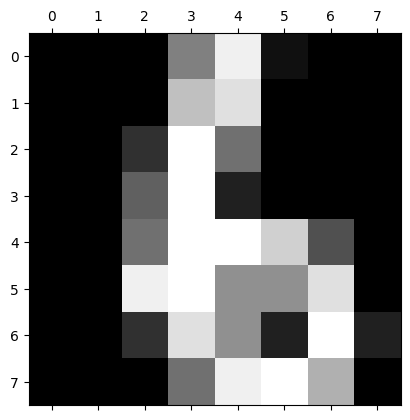

/tmp/ipykernel_815/991596568.py:11: RuntimeWarning: invalid value encountered in divide
  xtrain = (xtrain - means) / stds
/tmp/ipykernel_815/991596568.py:12: RuntimeWarning: invalid value encountered in divide
  xvalid = (xvalid - means) / stds
/tmp/ipykernel_815/991596568.py:13: RuntimeWarning: invalid value encountered in divide
  xtest = (xtest - means) / stds


In [132]:
digits = load_digits()
print(digits.data.shape)
x = digits.data
y = digits.target
plt.matshow(digits.images[16], cmap="gray")
plt.show()
xtrain, xvalidtest, ytrain, yvalidtest = train_test_split(x, y, test_size=0.4)
xvalid, xtest, yvalid, ytest = train_test_split(xvalidtest, yvalidtest, test_size=0.5)
means = xtrain.mean(axis=0)
stds = xtrain.std(axis=0)
xtrain = (xtrain - means) / stds
xvalid = (xvalid - means) / stds
xtest = (xtest - means) / stds

In [133]:
lrs = 1 / 2 ** np.arange(7)
epochs = 25
batches = 2 ** np.arange(7)
hiddenlairdim = 64
print(lrs)
print(len(np.unique(ytrain)))

[1.       0.5      0.25     0.125    0.0625   0.03125  0.015625]
10


In [ ]:
def testparams(lr, batches, xtrain, xvalid, ytrain, yvalid, epochs):
    rng = np.random.default_rng()
    model = Exercise.create_model(
        Exercise.create_linear_layer(xtrain.shape[1], hiddenlairdim, rng),
        Exercise.create_relu_layer(),
        Exercise.create_linear_layer(hiddenlairdim, len(np.unique(ytrain)), rng),
    )
    loss = Exercise.create_cross_entropy_loss()
    Exercise.train_model(
        model=model,
        loss=loss,
        x=xtrain,
        y=ytrain,
        lr=lr,
        n_epoch=epochs,
        batch_size=batches,
        shuffle=False,
    )
    predict = model.forward(xvalid)
    predicty = np.argmax(predict, axis=1)
    accuracy = np.mean(predicty == yvalid)

    return accuracy, model

In [ ]:
hyperparamacc = []
for lr in lrs:
    for batch in batches:
        acc, model = testparams(lr, batch, xtrain, xvalid, ytrain, yvalid, epochs)
        print(lr, " ", batch, " ", acc, "\n")
        hyperparamacc.append(tuple((acc, model, batch, lr)))

1.0   1   0.08913649025069638 

1.0   2   0.08913649025069638 

1.0   4   0.08913649025069638 

1.0   8   0.08913649025069638 

1.0   16   0.08913649025069638 

1.0   32   0.08913649025069638 

1.0   64   0.08913649025069638 

0.5   1   0.08913649025069638 



KeyboardInterrupt: 

In [ ]:
hyperparamacc.sort(key=lambda x: x[0])
bestmodel = hyperparamacc[0]
print("Best model hyperparams: \n")
print("Batches: ", bestmodel[2], "\n")
print("Learning rate: ", bestmodel[3], "\n")
print("Accuracy: ", bestmodel[0], "\n")

Best model hyperparams: 

Batches:  1 

Learning rate:  0.05 

Accuracy:  0.0947075208913649 

